## Shell Contact Example

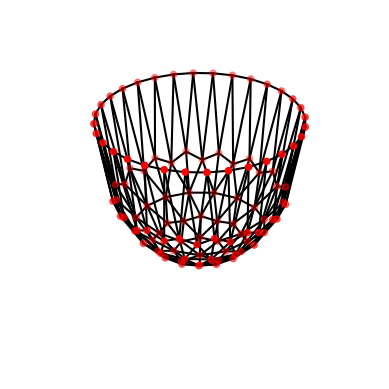

In [1]:
import numpy as np

import dismech


geom = dismech.GeomParams(rod_r0=0.005,
                          shell_h=0.001)

material = dismech.Material(density=1000,
                            youngs_rod=0,
                            youngs_shell=1e9,
                            poisson_rod=0,
                            poisson_shell=0.5)

shell_contact_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=True,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-3,
                                  max_iter=120,
                                  total_time=2.5,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2,
                                  use_predictor_corrector_for_ground_contact=True
                                )

env = dismech.Environment()
# env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('floorContact', ground_z=-1, stiffness=50, delta=1e-3, h=1e-3)
# env.add_force('selfContact', delta=1e-4, h=1e-3, kc=1)
env.add_force('damping', eta = 0.05)
#env.set_static()   

geo = dismech.Geometry.from_txt('../tests/resources/shell_contact/input_hemisphere_more_dense_inverted.txt')

robot = dismech.SoftRobot(geom, material, geo, shell_contact_sim, env)


fixed_points = np.array(np.where(
    (robot.state.q[:robot.end_node_dof_index].reshape(-1, 3)[:, 2] > -0.001) # (robot.state.q[:robot.end_node_dof_index].reshape(-1, 3)[:, 2] < 0.001)
)[0])

robot = robot.fix_nodes(fixed_points)



### Time Stepping

In [2]:
# before step function
# move the fixed nodes towards the ground with uniform speed

def push_into_ground(robot, t):
    # slowly increase the displacement of the last node to the right
    """ Simple example of a moving boundary condition """
        # [x, y, z]
    u0 = 0.1
        # [x, y, z]
    robot = robot.move_nodes(fixed_points, [0, 0, -u0 * robot.sim_params.dt])
    
    return robot

stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = push_into_ground

In [3]:
robots, t_arr, f_norms, Fs = stepper.simulate()

qs = np.stack([r.state.q for r in robots])
t_arr = np.array(t_arr[:len(qs)])

iter: 1, error: 912.905
iter: 2, error: 0.052
iter: 1, error: 964.364
iter: 2, error: 0.093
current_time:  0.001
iter: 1, error: 989.215
iter: 2, error: 1.158
iter: 1, error: 987.030
iter: 2, error: 0.137
current_time:  0.002
iter: 1, error: 964.161
iter: 2, error: 1.340
iter: 1, error: 962.077
iter: 2, error: 0.107
current_time:  0.003
iter: 1, error: 955.045
iter: 2, error: 1.683
iter: 1, error: 952.709
iter: 2, error: 0.079
current_time:  0.004
iter: 1, error: 954.609
iter: 2, error: 2.056
iter: 1, error: 951.911
iter: 2, error: 0.068
current_time:  0.005
iter: 1, error: 955.825
iter: 2, error: 2.422
iter: 1, error: 952.693
iter: 2, error: 0.067
current_time:  0.006
iter: 1, error: 956.728
iter: 2, error: 2.791
iter: 3, error: 0.001
iter: 1, error: 953.151
iter: 2, error: 0.068
current_time:  0.007
iter: 1, error: 957.229
iter: 2, error: 3.182
iter: 3, error: 0.001
iter: 1, error: 953.212
iter: 2, error: 0.070
current_time:  0.008
iter: 1, error: 957.597
iter: 2, error: 3.605
iter: 

In [6]:
options = dismech.AnimationOptions(
    title='Predictor-Corrector Hemisphere Contact',
    # z_lim=(robot.env.ground_z + robot.env.ground_h - 1e-3,
    #        qs[:, 2::3].max() + 1e-3),
    plot_step=1000
)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

In [5]:
# ani = dismech.get_animation(robot, t_arr, qs, options)
# ani.save('selfcontact_final.gif')